In [114]:
import matplotlib.pyplot as plt
from mxlpy import Simulator, make_protocol
from mxlmodels import get_lam2026
import pandas as pd

from mxlpy import Model
import numpy as np

In [115]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [116]:
# output = pd.read_csv("MATLAB_output.csv", names=["V", "A", "Z", "PV", "PA", "PZ", "QV", "QA", "QZ", "PL", "QL", "PSIId", "alpha_VDE", "P_free", "tau_inv"])
# output.index = output.index/10

In [117]:
protocol_5_10_5 = make_protocol([
    (1/60, {"ppfd": 0}),
    (5, {"ppfd": 1}),
    (10, {"ppfd": 0}),
    (5, {"ppfd": 1}),
])

protocol_baseline = make_protocol([
    (1/60, {"ppfd": 0}),
    (20, {"ppfd": 1}),
])

protocol_3_1_1_3_9_3 = make_protocol([
    (1/60, {"ppfd": 0}),
    (3, {"ppfd": 1}),
    (1, {"ppfd": 0}),
    (1, {"ppfd": 1}),
    (3, {"ppfd": 0}),
    (9, {"ppfd": 1}),
    (3, {"ppfd": 0}),
])

In [118]:
m_WT = get_lam2026()
s_WT = Simulator(m_WT).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_WT = s_WT.get_result().unwrap_or_err().get_combined()
m_WT = get_lam2026()
s_WT_baseline = Simulator(m_WT).simulate_protocol(protocol_baseline, time_points_per_step=100)
res_WT_baseline = s_WT_baseline.get_result().unwrap_or_err().get_combined()
m_WT = get_lam2026()
s_WT_311393 = Simulator(m_WT).simulate_protocol(protocol_3_1_1_3_9_3, time_points_per_step=100)
res_WT_311393 = s_WT_311393.get_result().unwrap_or_err().get_combined()


In [119]:
m_npq4npq1 = get_lam2026().update_parameters(
    {
        "tau_0": 1.283586052,
        "kappa_QV": 0,
        "kappa_QA": 0,
        "kappa_QZ": 0,
        "kappa_QL": 0,
        "kappa_qZ": 0,
    }
)
s_npq4npq1 = Simulator(m_npq4npq1).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_npq4npq1 = s_npq4npq1.get_result().unwrap_or_err().get_combined()

In [120]:
m_npq1 = (
    get_lam2026()
    .update_parameters(
    {
        "tau_0": 1.693954731,
        "kappa_qZ": 0,
        "V_tot_WT": 49.8,
    })
    .remove_reaction("VA")
    .remove_reaction("AV")
    .remove_reaction("AZ")
    .remove_reaction("ZA")
    .remove_reaction("PAf")
    .remove_reaction("PAb")
    .remove_reaction("PZf")
    .remove_reaction("PZb")
    .remove_reaction("QAb")
    .remove_reaction("QAf")
    .remove_reaction("QZf")
    .remove_reaction("QZb")
)
s_npq1 = Simulator(m_npq1).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_npq1 = s_npq1.get_result().unwrap_or_err().get_combined()


In [121]:
m_npq4 = (
    get_lam2026()
    .update_parameters(
    {
        "tau_0": 1.702050733,
        "V_tot_WT": 40.6,
        "kappa_QV": 0,
        "kappa_QA": 0,
        # "kappa_QZ": 0,
        "kappa_QL": 0,
    })
    .remove_reaction("QVf")
    .remove_reaction("QVb")
    .remove_reaction("QAb")
    .remove_reaction("QAf")
    .remove_reaction("QZf")
    .remove_reaction("QZb")
)
s_npq4 = Simulator(m_npq4).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_npq4 = s_npq4.get_result().unwrap_or_err().get_combined()


In [122]:
m_lut2 = (
    get_lam2026()
    .update_parameters(
    {
        "tau_0": 1.453352343,
        "V_tot_WT": 71.2,
        "k_PV_f": 1.43,
        "k_PV_b": 13.1,
        "k_PA_f": 34.4,
        "k_PA_b": 294,
        "k_PZ_f": 74.1,
        "k_PZ_b": 168,
    })
    .update_variables(
        {
            "PL": 49.9,
         }
    )
)
s_lut2 = Simulator(m_lut2).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_lut2 = s_lut2.get_result().unwrap_or_err().get_combined()


In [123]:
m_zep2 = (
    get_lam2026()
    .update_parameters(
    {
        "tau_0": 1.453352343,
        "V_tot_WT": 10.7,
        "X_tot": 11,
    })
)
s_zep2 = Simulator(m_zep2).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_zep2 = s_zep2.get_result().unwrap_or_err().get_combined()


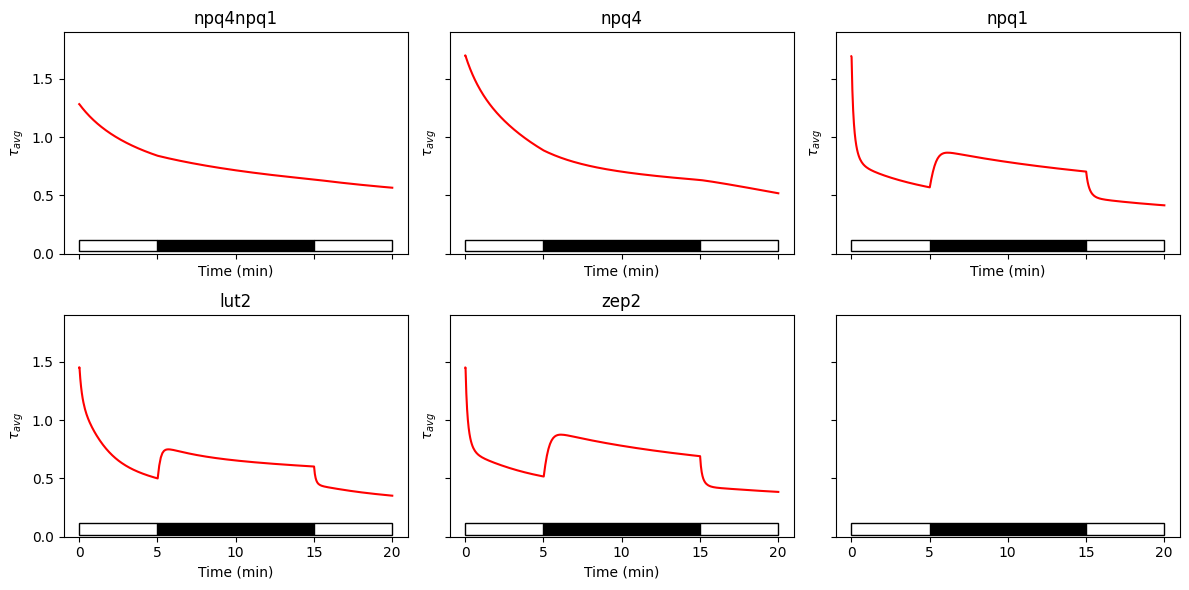

In [124]:
from matplotlib.patches import Rectangle

fig, axs = plt.subplots(ncols = 3, nrows = 2, figsize = (12, 6), sharey= True, sharex= True)

res_list = [res_npq4npq1, res_npq4, res_npq1, res_lut2, res_zep2]
label_list = ["npq4npq1", "npq4", "npq1", "lut2","zep2"]

for ax, res, label in zip(axs.flatten(), res_list, label_list):
    ax.plot(res.index, res["tau_Fluo"], label = label, color = "red")
    ax.set_ylim(0,1.9)
    ax.set_ylabel(r"$\tau_{avg}$")
    ax.set_xlabel("Time (min)")
    ax.set_title(label)

for ax in axs.flatten():
    ax.add_patch(Rectangle(
        (5, 0.01), 10, 0.05,       # x, y, width, height in data coords
        transform=ax.get_xaxis_transform(),  # x: data, y: axes fraction
        clip_on=False, facecolor="black", zorder=5, edgecolor ='black'))
    ax.add_patch(Rectangle(
        (0, 0.01), 5, 0.05,       # x, y, width, height in data coords
        transform=ax.get_xaxis_transform(),  # x: data, y: axes fraction
        clip_on=False, facecolor="white", zorder=5, edgecolor ='black'))
    ax.add_patch(Rectangle(
        (15, 0.01), 5, 0.05,       # x, y, width, height in data coords
        transform=ax.get_xaxis_transform(),  # x: data, y: axes fraction
        clip_on=False, facecolor="white", zorder=5, edgecolor ='black'))

fig.tight_layout()

In [125]:
m_npq1lut2 = (
    get_lam2026()
    .update_parameters(
    {
        "tau_0": 1.453352343,
        "V_tot_WT": 49.8,#71.2, #
        "X_tot": 49.8+1,#71.2+1,#
        "k_PV_f": 1.43,
        "k_PV_b": 13.1,
        "k_PA_f": 34.4,
        "k_PA_b": 294,
        "k_PZ_f": 74.1,
        "k_PZ_b": 168,
        "kappa_qI": 7.04,
    })
    .remove_reaction("VA")
    .remove_reaction("AV")
    .remove_reaction("AZ")
    .remove_reaction("ZA")
    .remove_reaction("PAf")
    .remove_reaction("PAb")
    .remove_reaction("PZf")
    .remove_reaction("PZb")
    .remove_reaction("QAb")
    .remove_reaction("QAf")
    .remove_reaction("QZf")
    .remove_reaction("QZb")
    .update_variables(
        {
            "PL": 49.9,
         }
    )
)
s_npq1lut2 = Simulator(m_npq1lut2).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_npq1lut2 = s_npq1lut2.get_result().unwrap_or_err().get_combined()


In [126]:
m_zep2lut2 = (
    get_lam2026()
    .update_parameters(
    {
        "tau_0": 1.453352343,
        "V_tot_WT": 10.7,
        "X_tot": 11,
        "k_PV_f": 1.43,
        "k_PV_b": 13.1,
        "k_PA_f": 34.4,
        "k_PA_b": 294,
        "k_PZ_f": 74.1,
        "k_PZ_b": 168,
        "kappa_qI": 7.04,
    })
    .update_variables(
        {
            "PL": 49.9,
         }
    )
)
s_zep2lut2 = Simulator(m_zep2lut2).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_zep2lut2 = s_zep2lut2.get_result().unwrap_or_err().get_combined()


In [127]:
m_npq4lut2 = (
    get_lam2026()
    .update_parameters(
    {
        "tau_0": 1.453352343,
        "V_tot_WT": 40.6,
        "X_tot": 41.6,
        "kappa_QV": 0,
        "kappa_QA": 0,
        "kappa_QL": 0,
        "k_PV_f": 1.43,
        "k_PV_b": 13.1,
        "k_PA_f": 34.4,
        "k_PA_b": 294,
        "k_PZ_f": 74.1,
        "k_PZ_b": 168,
        "kappa_qI": 7.04,
    })
    .remove_reaction("QVf")
    .remove_reaction("QVb")
    .remove_reaction("QAb")
    .remove_reaction("QAf")
    .remove_reaction("QZf")
    .remove_reaction("QZb")
    .update_variables(
        {
            "PL": 49.9,
         }
    )
)
s_npq4lut2 = Simulator(m_npq4lut2).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_npq4lut2 = s_npq4lut2.get_result().unwrap_or_err().get_combined()


In [128]:
m_npq4zep2 = (
    get_lam2026()
    .update_parameters(
    {
        "tau_0": 1.453352343,
        "V_tot_WT": 10.7,
        "X_tot": 11,
        "kappa_QV": 0,
        "kappa_QA": 0,
        "kappa_QL": 0,
        "kappa_qI": 7.04,
    })
    .remove_reaction("QVf")
    .remove_reaction("QVb")
    .remove_reaction("QAb")
    .remove_reaction("QAf")
    .remove_reaction("QZf")
    .remove_reaction("QZb")
)
s_npq4zep2 = Simulator(m_npq4zep2).simulate_protocol(protocol_5_10_5, time_points_per_step=100)
res_npq4zep2 = s_npq4zep2.get_result().unwrap_or_err().get_combined()


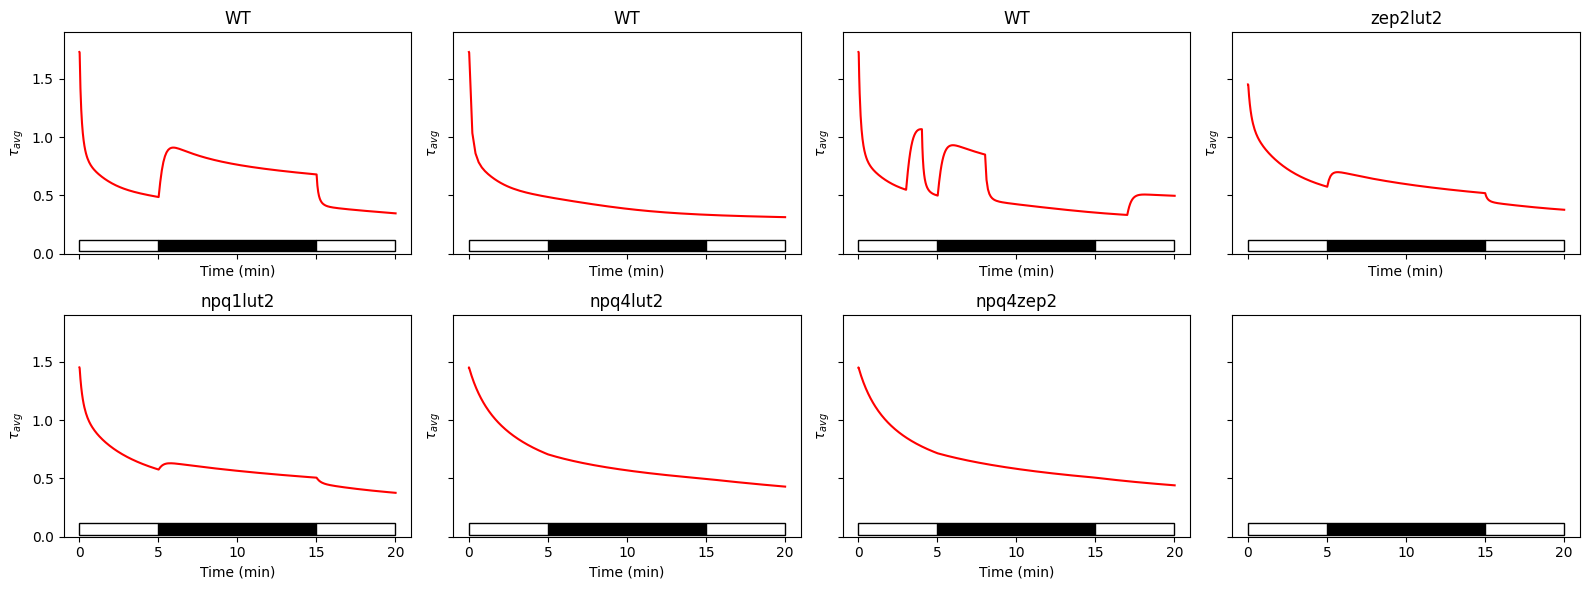

In [129]:
from matplotlib.patches import Rectangle

fig, axs = plt.subplots(ncols = 4, nrows = 2, figsize = (16, 6), sharey= True, sharex= True)

res_list = [res_WT, res_WT_baseline, res_WT_311393, res_zep2lut2, res_npq1lut2, res_npq4lut2, res_npq4zep2]
label_list = ["WT", "WT", "WT", "zep2lut2", "npq1lut2", "npq4lut2", "npq4zep2"]

for ax, res, label in zip(axs.flatten(), res_list, label_list):
    ax.plot(res.index, res["tau_Fluo"], label = label, color = "red")
    ax.set_ylim(0,1.9)
    ax.set_ylabel(r"$\tau_{avg}$")
    ax.set_xlabel("Time (min)")
    ax.set_title(label)

for ax in axs.flatten():
    ax.add_patch(Rectangle(
        (5, 0.01), 10, 0.05,       # x, y, width, height in data coords
        transform=ax.get_xaxis_transform(),  # x: data, y: axes fraction
        clip_on=False, facecolor="black", zorder=5, edgecolor ='black'))
    ax.add_patch(Rectangle(
        (0, 0.01), 5, 0.05,       # x, y, width, height in data coords
        transform=ax.get_xaxis_transform(),  # x: data, y: axes fraction
        clip_on=False, facecolor="white", zorder=5, edgecolor ='black'))
    ax.add_patch(Rectangle(
        (15, 0.01), 5, 0.05,       # x, y, width, height in data coords
        transform=ax.get_xaxis_transform(),  # x: data, y: axes fraction
        clip_on=False, facecolor="white", zorder=5, edgecolor ='black'))

fig.tight_layout()

In [130]:
def mul(x,y):
    return x*y
def add_con(m:Model) -> Model:
    m = (
    m
    .add_readout("NPQ_V", mul, args = ["kappa_QV", "QV"])
    .add_readout("NPQ_A", mul, args = ["kappa_QA", "QA"])
    .add_readout("NPQ_Z_qE", mul, args = ["kappa_QZ", "QZ"])
    .add_readout("NPQ_L", mul, args = ["kappa_QL", "QL"])
    .add_readout("NPQ_Z_qZ", mul, args = ["kappa_qZ", "Z"])
    )
    return m

con_WT = Simulator(add_con(m_WT)).simulate(1e-6).update_parameter('ppfd',1).simulate_time_course(np.linspace(1,20,20)).get_result().unwrap_or_err().get_combined()
con_npq1 = Simulator(add_con(m_npq1)).simulate(1e-6).update_parameter('ppfd',1).simulate_time_course(np.linspace(1,20,20)).get_result().unwrap_or_err().get_combined()
con_npq4 = Simulator(add_con(m_npq4)).simulate(1e-6).update_parameter('ppfd',1).simulate_time_course(np.linspace(1,20,20)).get_result().unwrap_or_err().get_combined()
con_zep2 = Simulator(add_con(m_zep2)).simulate(1e-6).update_parameter('ppfd',1).simulate_time_course(np.linspace(1,20,20)).get_result().unwrap_or_err().get_combined()
con_lut2 = Simulator(add_con(m_lut2)).simulate(1e-6).update_parameter('ppfd',1).simulate_time_course(np.linspace(1,20,20)).get_result().unwrap_or_err().get_combined()
con_npq4npq1 = Simulator(add_con(m_npq4npq1)).simulate(1e-6).update_parameter('ppfd',1).simulate_time_course(np.linspace(1,20,20)).get_result().unwrap_or_err().get_combined()

In [ ]:
res_list= [con_npq4npq1, con_npq4, con_npq1, con_lut2, con_zep2, con_WT]
timepoints = [1, 3, 5, 20]

fig, axs = plt.subplots(ncols= 2, nrows =2, figsize = (8, 8))

for ax, time in zip(axs.flatten(), timepoints):
    for res in res_list:
        df = res.loc[time]


V                19.255287
A                14.675105
Z                 0.566256
PV               13.385821
PA               21.568657
PZ                3.780683
QV                1.934093
QA                1.634850
QZ                0.222902
QL                2.473200
PL              162.526800
PSIId             0.046276
alpha_VDE         0.570736
PSII_active       0.953724
P_free            2.872993
tau_Fluo          0.548828
NPQ_V             0.077364
NPQ_A             0.284464
NPQ_Z_qE          0.039454
NPQ_L             0.647978
NPQ_Z_qZ          0.016988
VA               27.144538
AV               16.436117
AZ                4.187808
ZA                0.039638
PVf             120.598268
PVb             126.228292
PAf            5480.991661
PAb            5478.438858
PZf             479.920637
PZb             476.366105
QVf               0.361417
QVb               0.127650
QAf              14.235314
QAb              14.010668
QZf               2.117183
QZb               1.910271
Q